# ECT Sensor – Exploratory Data Analysis

## Purpose
Explores the COMSOL-simulated EM sensor dataset.  
Inverse Problem: Given a multi frequency eddy current signal, predict relative permeability (μr) and resistivity (ρ) for the material.

## Raw Structure
- 5 resistivity values and 11 permeability values = 55 unique combinations
- across 8 frequencies (375 Hz- 48 kHz)
- raw format = 5x11x8 = 440 rows, one per μr/ρ/frequency combination 
- The two receiver coils (coil 2, coil 3) return complex mutual-inductance values; their difference gives the differential (gradiometer) signal used for inversion.

## EDA Goals
1. Analyse the signals and response to each target
2. Identifiy which frequencies contain the most information for each target (sensitivity analysis)
3. Measure how predictably each feature varies with each target (correlation analysis)
4. PCA for multivariate analysis

These findings directly inform modelling decisions: feature selection, validation strategy,
and expected model difficulty per target.

In [3]:
import sys
from pathlib import Path

# Add project root to path 
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

# Figures folder path
fig_dir = project_root/"figures"
fig_dir.mkdir(exist_ok=True)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FixedFormatter

## 1. Load raw

Raw output from COMSOL exported to Excel. `header=4` skips the first four rows of COMSOL metadata so pandas reads the correct column-name row.

In [4]:
from src.data import load_raw,rename_columns, compute_differential

raw = load_raw()
print('Shape:',raw.shape)
raw.head()

Shape: (440, 7)


,% MP,res,freq (Hz),real(mf.VCoil_2/(mf.ICoil_1*mf.omega*1j)) (H),imag(mf.VCoil_2/(mf.ICoil_1*mf.omega*1j)) (H),real(mf.VCoil_3/(mf.ICoil_1*mf.omega*1j)) (H),imag(mf.VCoil_3/(mf.ICoil_1*mf.omega*1j)) (H)
0,50,2.000000e-07,375,0.000582,-0.000002,0.000662,-0.000100
1,50,2.000000e-07,750,0.000584,0.000011,0.000603,-0.000167
2,50,2.000000e-07,1500,0.000602,0.000019,0.000480,-0.000209
3,50,2.000000e-07,3000,0.000622,0.000003,0.000359,-0.000172
4,50,2.000000e-07,6000,0.000621,-0.000030,0.000304,-0.000121


In [5]:
raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 7 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   % MP                                           440 non-null    int64  
 1   res                                            440 non-null    float64
 2   freq (Hz)                                      440 non-null    int64  
 3   real(mf.VCoil_2/(mf.ICoil_1*mf.omega*1j)) (H)  440 non-null    float64
 4   imag(mf.VCoil_2/(mf.ICoil_1*mf.omega*1j)) (H)  440 non-null    float64
 5   real(mf.VCoil_3/(mf.ICoil_1*mf.omega*1j)) (H)  440 non-null    float64
 6   imag(mf.VCoil_3/(mf.ICoil_1*mf.omega*1j)) (H)  440 non-null    float64
dtypes: float64(5), int64(2)
memory usage: 24.2 KB


## 2. Rename Columns

COMSOL exports verbose expression strings as column headers. Rename to short, readable names used throughout the rest of the notebook.

In [6]:
raw = rename_columns(raw)
print(raw.columns.tolist())

print(f'\nUnique Permeabilities ({len(raw["permeability"].unique())}): {sorted(raw["permeability"].unique())}')
print(f'Unique Resistivities ({len(raw["resistivity"].unique())}): {sorted(raw["resistivity"].unique())}')
print(f'Unique Frequencies ({len(raw["frequency"].unique())}): {sorted(raw["frequency"].unique())}')

['permeability', 'resistivity', 'frequency', 'coil2_real', 'coil2_imag', 'coil3_real', 'coil3_imag']

Unique Permeabilities (11): [np.int64(50), np.int64(100), np.int64(200), np.int64(300), np.int64(400), np.int64(500), np.int64(600), np.int64(700), np.int64(800), np.int64(900), np.int64(1000)]
Unique Resistivities (5): [np.float64(2e-07), np.float64(4e-07), np.float64(6e-07), np.float64(8e-07), np.float64(1e-06)]
Unique Frequencies (8): [np.int64(375), np.int64(750), np.int64(1500), np.int64(3000), np.int64(6000), np.int64(12000), np.int64(24000), np.int64(48000)]


## 3. Differential (Gradiometer) Inductance

The sensor uses a gradiometer configuration: coil 2 and coil 3 are wound in opposition so that the common-mode background signal cancels.  
Subtracting coil 3 from coil 2 gives the net differential mutual inductance **H**, whose real and imaginary parts carry the material response.  
The sign of H depends on coil orientation in the COMSOL model; if the mean is negative the sign is flipped to match physical convention.
$$H = \text{coil}_2 - \text{coil}_3$$
### Physical Meaning of H
- H_Real = represents the in-phase component. captures how sttrongly the material magnetises in response to the sensor's field. Dominated by **permeability**
- H_Imag = represents the out-of-phase component. captures energy loss due to eddy current flowing inside the material. Dominated by **resistivity**

In [7]:
raw = compute_differential(raw)

print(f"H_real mean: {raw['H_real'].mean():.6f}  (should be positive after sign correction)")
print(f"H_imag mean: {raw['H_imag'].mean():.6f}  (should be positive after sign correction)")
print()
raw[['frequency', 'H_real', 'H_imag']].head(10)

H_real mean: 0.000225  (should be positive after sign correction)
H_imag mean: 0.000102  (should be positive after sign correction)



,frequency,H_real,H_imag
0,375,-0.000079,0.000097
1,750,-0.000018,0.000178
2,1500,0.000122,0.000228
3,3000,0.000263,0.000175
4,6000,0.000318,0.000091
5,12000,0.000324,0.000041
6,24000,0.000325,0.000023
7,48000,0.000333,0.000011
8,375,-0.000069,0.000098
9,750,-0.000010,0.000177


In [8]:
raw.describe()

,permeability,resistivity,frequency,H_real,H_imag
count,440.000000,4.400000e+02,440.000000,440.000000,440.000000
mean,504.545455,6.000000e-07,11953.125000,0.000225,0.000102
std,309.643447,2.831647e-07,15545.616253,0.000154,0.000078
min,50.000000,2.000000e-07,375.000000,-0.000079,-0.000003
25%,200.000000,4.000000e-07,1312.500000,0.000098,0.000031
50%,500.000000,6.000000e-07,4500.000000,0.000312,0.000094
75%,800.000000,8.000000e-07,15000.000000,0.000347,0.000175
max,1000.000000,1.000000e-06,48000.000000,0.000366,0.000228


In [9]:
raw.head()

,permeability,resistivity,frequency,H_real,H_imag
0,50,2.000000e-07,375,-0.000079,0.000097
1,50,2.000000e-07,750,-0.000018,0.000178
2,50,2.000000e-07,1500,0.000122,0.000228
3,50,2.000000e-07,3000,0.000263,0.000175
4,50,2.000000e-07,6000,0.000318,0.000091


## 4. Visualise Inductance vs Frequency

Four subplots in a 2×2 grid:
- **Top row** — fix resistivity, vary permeability across all  μr values.  
- **Bottom row** — fix permeability, vary resistivity across all  ρ values.  
- **Left column** — real part of H (in phase with excitation; linked to permeability).  
- **Right column** — imaginary part of H (out of phase; linked to eddy-current losses / conductivity).  


**Skin depth physics:**
The key physical principle governing all four subplots is **skin depth** — the depth to which
the sensor's field penetrates the material:
$$\delta = \sqrt{\frac{\rho}{\pi f \mu}}$$

- Higher frequency -> shallower skin depth -> signal only sees the surface
- Higher μr -> shallower skin depth (stronger eddy currents oppose field penetration)
- Higher ρ -> deeper skin depth (weaker eddy currents, less opposition)

**Note:** Fixed values are chosen at the middle of each parameter range to give a
representative view. Behaviour is consistent across other fixed values.

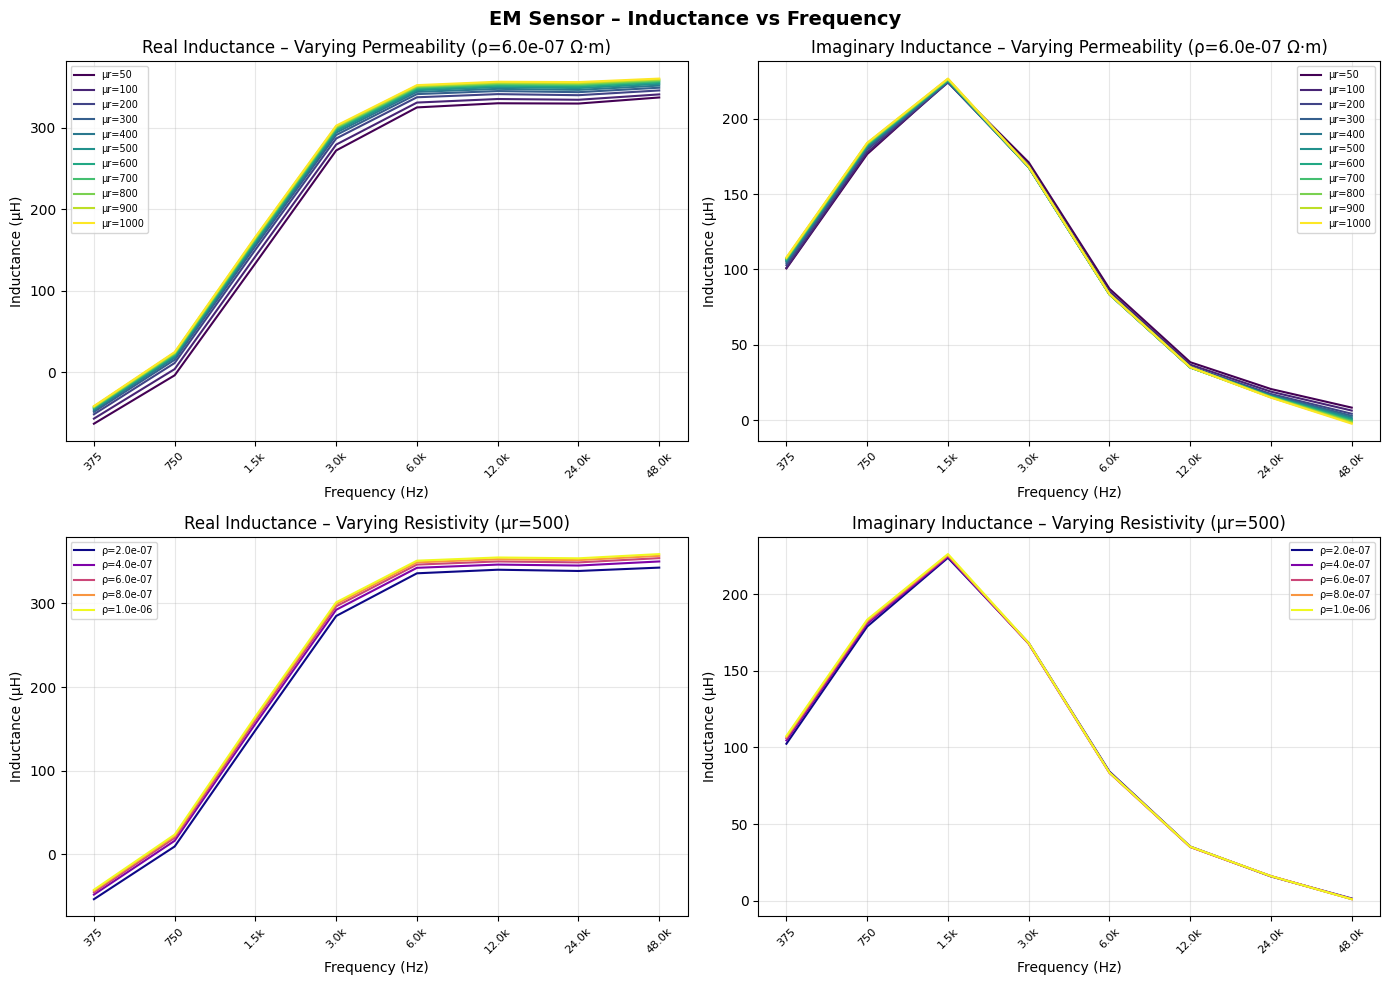

In [10]:
# Sorted unique parameter values across the simulation sweep
permeabilities = sorted(raw['permeability'].unique())
resistivities  = sorted(raw['resistivity'].unique())

# Choose fixed values for the "vary-one" subplots (lowest value in each sweep)
res_fixed  = resistivities[len(resistivities) // 2]
perm_fixed = permeabilities[len(permeabilities) // 2]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('EM Sensor – Inductance vs Frequency', fontsize=14, fontweight='bold')

# --- Top row: vary permeability, fix resistivity ---
# Isolate rows with the fixed resistivity, then loop over all μr values.
subset1 = raw[raw['resistivity'] == res_fixed]
colors1  = plt.get_cmap('viridis')(np.linspace(0, 1, len(permeabilities)))

for i, perm in enumerate(permeabilities):
    g = subset1[subset1['permeability'] == perm].sort_values('frequency')
    # Scale H from H to μH for readability
    axes[0, 0].plot(g['frequency'], g['H_real'] * 1e6, color=colors1[i], label=f'μr={int(perm)}')
    axes[0, 1].plot(g['frequency'], g['H_imag'] * 1e6, color=colors1[i], label=f'μr={int(perm)}')

axes[0, 0].set_title(f'Real Inductance – Varying Permeability (ρ={res_fixed:.1e} Ω·m)')
axes[0, 1].set_title(f'Imaginary Inductance – Varying Permeability (ρ={res_fixed:.1e} Ω·m)')

# --- Bottom row: vary resistivity, fix permeability ---
subset2 = raw[raw['permeability'] == perm_fixed]
colors2  = plt.get_cmap('plasma')(np.linspace(0, 1, len(resistivities)))

for i, res in enumerate(resistivities):
    g = subset2[subset2['resistivity'] == res].sort_values('frequency')
    axes[1, 0].plot(g['frequency'], g['H_real'] * 1e6, color=colors2[i], label=f'ρ={res:.1e}')
    axes[1, 1].plot(g['frequency'], g['H_imag'] * 1e6, color=colors2[i], label=f'ρ={res:.1e}')

axes[1, 0].set_title(f'Real Inductance – Varying Resistivity (μr={int(perm_fixed)})')
axes[1, 1].set_title(f'Imaginary Inductance – Varying Resistivity (μr={int(perm_fixed)})')

# --- Shared formatting ---
# Use the exact simulated frequencies as x-ticks on a log scale.
freq_ticks  = sorted(raw['frequency'].unique())
freq_labels = [f'{f/1000:.1f}k' if f >= 1000 else str(int(f)) for f in freq_ticks]

for ax in axes.flat:
    ax.set_xlabel('Frequency (Hz)')
    ax.set_ylabel('Inductance (μH)')
    ax.legend(fontsize=7)
    ax.set_xscale('log')
    ax.set_xticks(freq_ticks)
    ax.set_xticklabels(freq_labels, rotation=45, fontsize=8)
    ax.get_xaxis().set_major_formatter(FixedFormatter(freq_labels))
    ax.minorticks_off()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(fig_dir/'inductance_plots.png', dpi=150, bbox_inches='tight')
plt.show()

**Key Observations from the Plot:**
- **H_Real-Varying Permeability:** Strong line separation at low-mid frequencies and convergence at high frequencies. This means μr information is concentrated at low-mid frequencies. The trajectory of the plot also aligns with the physics  because at low - mid frequencies, eddy currents are still weak and cannot generate magnetic field to oppose the signal hence the rise but the signal eventually flattens once eddy currents are strong enough. Additionally, at high frequencies the sensor signal is limited to the surface of the material at all permeability values due to decreased skin depth, hence the convergence. 

- **H_Imaginary-Varying Permeability:** Poor line separation between the plots. This is expected because μr is associated with the magnetic response of the material and H_Imaginary measures energy loss due to Eddy Current in the material hence the variation in permeability does not make much difference. The trajectory of the plots is also in line with the physics. As eddy current is induced in the material, energy is lost while driving the current through the material. The energy loss keeps increasing till mid frequency and starts droping at higher frequencies. This is because skin depth decreases at higher frequencies, due to which the eddy currents are limited to the surface of the material which means lesser area for the current which implies lesser energy lost to drive it. Also, a flip in the order of signals at high frequencies can be observed. This is because at low frequenices, permeability can  increase induced eddy currents which leads to more energy loss, driving H_imag upwards with μr. But at high frequencies where skin depth is shallow, higher μr makes it shallower, confining eddy currents to even thinner surface layer which means even less energy loss, pushing H_imag down with μr. Hence the divergence at 48kHz.

- **H_Imaginary-Varying Resistivity:** Poor line separation between the plots. This means that H_Imaginary carries little information on ρ. Physically, ρ controls eddy current strength. Higher ρ means higher skin depth effect(signal penetrates deeper). High skin depth means larger area for the eddy current to be driven through which weakens eddy currents which means lower H_imag values. This means downward separation between plots but we don't see it probably beacuse the range of ρ is too narrow to see the difference.

- **H_Real-Varying Resistivity:** Some degree of line separation exists between the plots. Weaker eddy currents generate a weaker opposing MF, resulting in less reduction of H_real and stronger eddy currents results in more reduction of H_real. Even though H_real is primarily μr-dominated, ρ, which governs the strength of eddy currents, has a secondary effect on H_real. So ρ has an effect on H_real but its weaker than its effect on H_imag.

## 5.Signal Sensitivity Analysis

The goal of this analysis is to identify at which frequencies, the signal change the most when the target variables change. The frequenicies with more signal change will have more information on target varibles which can be used to predict them. 

For this, Standard Deviation of signals is calculated across target variables, per frequency.
- Large SD at a frequency-> signals vary a lot across different target values -> high information content
- Low SD at a frequency -> signals are bunched together -> low information content

To avoid dependance on a single fixed value,
1. Group By(frequency, fixed-param) : this gives one group per fixed-param value per frequency
2. Compute SD across the varying target within each group
3. Average across all fixed-param value groups -> one single sensitivity estimate per frequency

Computations are done all 4 combination(H_real & H_imag for both targets) to check if information leaks to other components.

Caveat: SD measures absolute spread between materials. A large SD can still mean poor separation relative to the signal size beacause SD discards the baseline. so a high SD alone doesn't confirm that the materials are well-separated, though a near-zero SD confirms they aren't.

In [11]:
#μr sensitivity: how much does the signal vary across μr values at each frequency?
# Group By(frequency, resistivity) -> SD across  H_real/H_imag values for each of the 11 μr values -> repeat for all 5 ρ groups -> take average
mu_sens_real = raw.groupby(['frequency', 'resistivity'])['H_real'].std().groupby('frequency').mean()
mu_sens_imag = raw.groupby(['frequency', 'resistivity'])['H_imag'].std().groupby('frequency').mean()

#ρ sensitivity: how much does the signal vary across ρ values at each frequency?
# Group By(frequency, permeability) -> SD across  H_real/H_imag values for each of the 5 ρ values -> repeat for all 11 μr groups -> take average
rho_sens_real = raw.groupby(['frequency', 'permeability'])['H_real'].std().groupby('frequency').mean()
rho_sens_imag = raw.groupby(['frequency', 'permeability'])['H_imag'].std().groupby('frequency').mean()

print('μr sensitivity (H_real SD)')
print((mu_sens_real * 1e6).round(3).map(lambda x: f"{x} μH").to_string())
print('\n')
print('μr sensitivity (H_imag SD)')
print((mu_sens_imag * 1e6).round(3).map(lambda x: f"{x} μH").to_string())
print('\n')
print('ρ sensitivity (H_real SD)')
print((rho_sens_real * 1e6).round(3).map(lambda x: f"{x} μH").to_string())
print('\n')
print('ρ sensitivity (H_imag SD)')
print((rho_sens_imag * 1e6).round(3).map(lambda x: f"{x} μH").to_string())

μr sensitivity (H_real SD)
frequency
375       7.429 μH
750       9.264 μH
1500     10.359 μH
3000      9.723 μH
6000      8.726 μH
12000     8.416 μH
24000      8.24 μH
48000     6.987 μH


μr sensitivity (H_imag SD)
frequency
375      2.363 μH
750      2.158 μH
1500     1.102 μH
3000     1.178 μH
6000     1.342 μH
12000    1.347 μH
24000    2.115 μH
48000    3.565 μH


ρ sensitivity (H_real SD)
frequency
375      5.067 μH
750      6.041 μH
1500     6.575 μH
3000     6.303 μH
6000     5.688 μH
12000    5.464 μH
24000    5.675 μH
48000    6.122 μH


ρ sensitivity (H_imag SD)
frequency
375      2.154 μH
750      1.549 μH
1500     1.023 μH
3000     0.695 μH
6000     0.691 μH
12000    0.788 μH
24000    1.018 μH
48000    0.874 μH


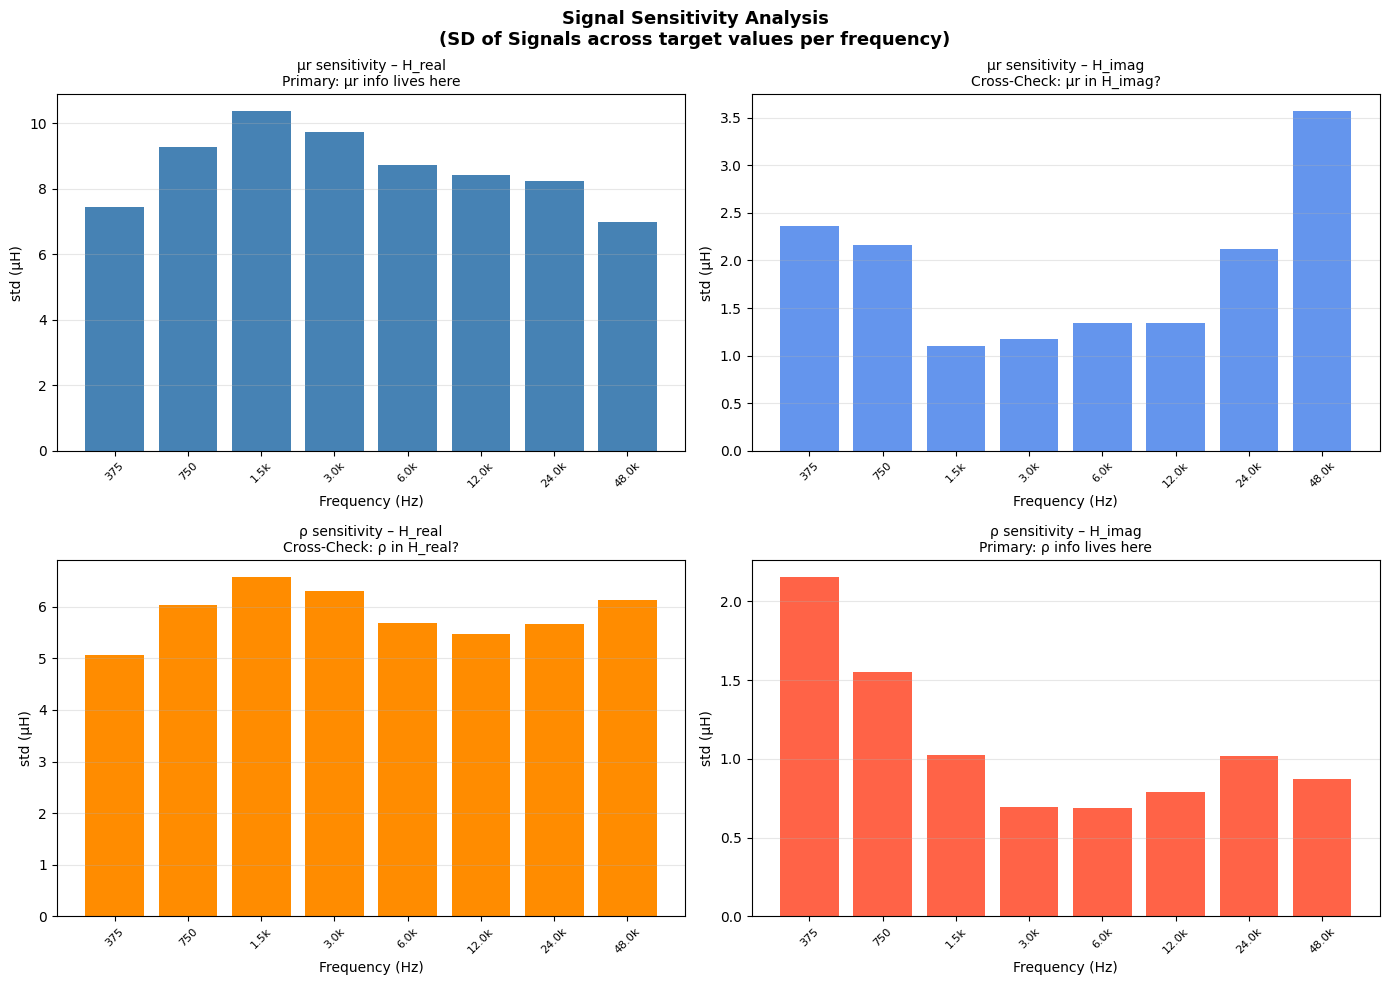

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Signal Sensitivity Analysis\n(SD of Signals across target values per frequency)',
             fontsize=13, fontweight='bold')

plot_data = [
    (axes[0,0], mu_sens_real, 'μr sensitivity – H_real', 'steelblue', 'Primary: μr info lives here'),
    (axes[0,1], mu_sens_imag, 'μr sensitivity – H_imag', 'cornflowerblue', 'Cross-Check: μr in H_imag?'),
    (axes[1,0], rho_sens_real, 'ρ sensitivity – H_real', 'darkorange', 'Cross-Check: ρ in H_real?'),
    (axes[1,1], rho_sens_imag, 'ρ sensitivity – H_imag', 'tomato', 'Primary: ρ info lives here')
]

for ax, sens, title, colour, subtitle in plot_data:
    ax.bar(range(len(freq_ticks)),sens.values * 1e6, color=colour)
    ax.set_title(f'{title}\n{subtitle}', fontsize=10)
    ax.set_xlabel('Frequency (Hz)')
    ax.set_ylabel('std (μH)')
    ax.set_xticks(range(len(freq_ticks)))
    ax.set_xticklabels(freq_labels, rotation=45, fontsize=8)
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(fig_dir/'sensitivity_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

- μr - H_real (Primary): Peaks at mid-frequencies (1.5k-3.0kHz) and lower at extremes.

- μr - H_imag (Cross-Check): Very low SD throughout with a slight uptick at 48kHz. Consistent with the physical expectation that μr has minimal effect on H_imag compared to H_real

- ρ - H_real (Cross-Check): Fairly flat and consistent across frequencies. ρ has some effect on H_real as physically expected

- ρ - H_imag (Primary): Highest at 375Hz and decreasing as frequency increses.

## 6. Spearman Correlation Analysis

While SD caluclated the variation of input features across target variables, Spearman measures the strength and direction of monotonic relationship between features and targets. It  measures the increase or decrease in features as the targets change.

In [13]:
# Spearman's Correlation
from src.data import reshape_wide

wide_df = reshape_wide(raw)

sp_corr = wide_df.corr(method='spearman')

# Extract only the feature columns
feature_cols = [c for c in wide_df.columns if c not in ['permeability', 'resistivity']]

mu_corr = sp_corr.loc[feature_cols, 'permeability']
rho_corr = sp_corr.loc[feature_cols, 'resistivity']

print(f"Spearman Correlation with permeability:\n{mu_corr.round(3).to_string()}\n")
print(f"Spearman Correlation with resistivity:\n{rho_corr.round(3).to_string()}\n")
print(f"Targets Correlation: {sp_corr.loc['permeability', 'resistivity']:.3f}")

Spearman Correlation with permeability:
H_imag_375      0.727
H_imag_750      0.787
H_imag_1500     0.520
H_imag_3000    -0.402
H_imag_6000    -0.598
H_imag_12000   -0.603
H_imag_24000   -0.878
H_imag_48000   -0.975
H_real_375      0.775
H_real_750      0.786
H_real_1500     0.790
H_real_3000     0.779
H_real_6000     0.796
H_real_12000    0.811
H_real_24000    0.797
H_real_48000    0.733

Spearman Correlation with resistivity:
H_imag_375      0.650
H_imag_750      0.530
H_imag_1500     0.390
H_imag_3000     0.164
H_imag_6000     0.012
H_imag_12000    0.162
H_imag_24000    0.152
H_imag_48000    0.019
H_real_375      0.573
H_real_750      0.562
H_real_1500     0.542
H_real_3000     0.560
H_real_6000     0.548
H_real_12000    0.524
H_real_24000    0.532
H_real_48000    0.596

Targets Correlation: 0.000


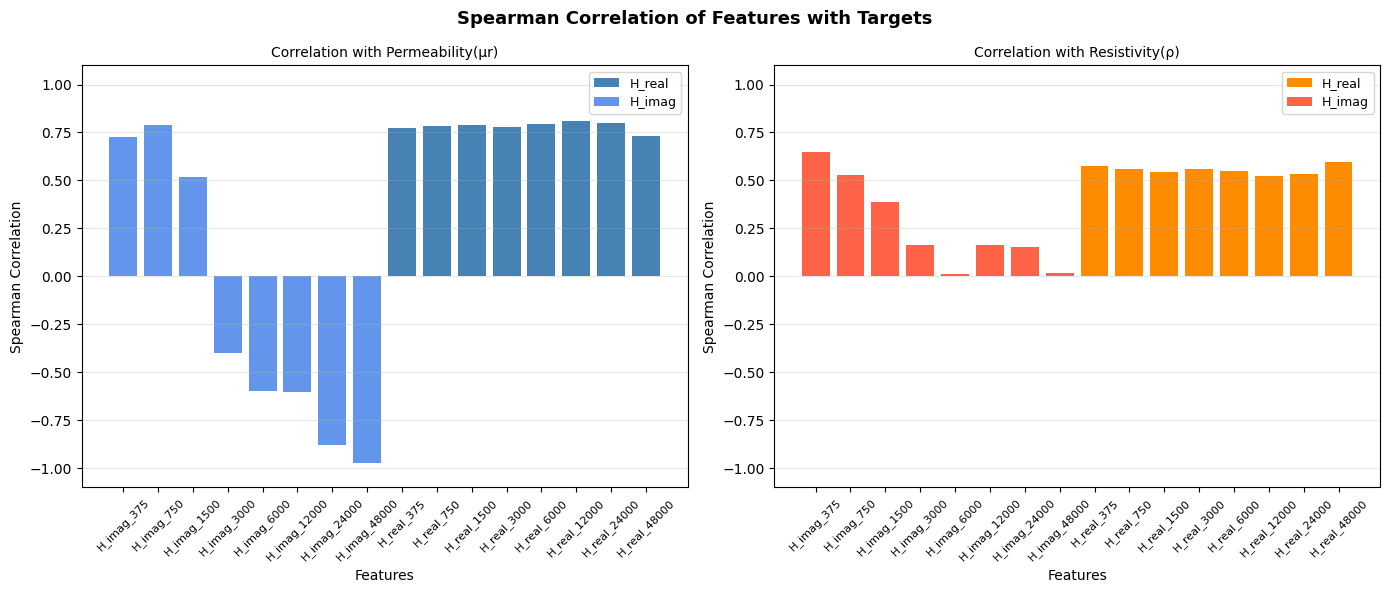

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Spearman Correlation of Features with Targets',
             fontsize=13, fontweight='bold')

x = np.arange(len(feature_cols))


colours_mu = ['steelblue' if 'real' in c else 'cornflowerblue' for c in feature_cols]
colours_rho = ['darkorange' if 'real' in c else 'tomato' for c in feature_cols]

corr_plot_data = [
    (axes[0], mu_corr, 'Correlation with Permeability(μr)', colours_mu),
    (axes[1], rho_corr, 'Correlation with Resistivity(ρ)', colours_rho)
]

for ax, corr, title, colour in corr_plot_data:
    ax.bar(x, corr.values, color=colour)
    ax.set_title(f'{title}', fontsize=10)
    ax.set_xlabel('Features')
    ax.set_ylabel('Spearman Correlation')
    ax.set_ylim(-1.1, 1.1)
    ax.set_xticks(x)
    ax.set_xticklabels(feature_cols, rotation=45, fontsize=8)
    ax.grid(True, alpha=0.3, axis='y')

# Add Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='steelblue', label='H_real'), 
                   Patch(facecolor='cornflowerblue', label='H_imag')]
axes[0].legend(handles=legend_elements, fontsize=9)
legend_elements2 = [Patch(facecolor='darkorange', label='H_real'), 
                   Patch(facecolor='tomato', label='H_imag')]
axes[1].legend(handles=legend_elements2, fontsize=9)

plt.tight_layout()
plt.savefig(fig_dir/'correlation_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

- Permeability (μr)
    - H_Real: High positive correlation consistent across frequencies. This contradicts the sensitivity analysis which suggested mid-frequency dominance. This is because SD measures abolute variation whereas Spearman measures monotonicity
    - H_Imag: High positive correlation at low frequencies before flipping to strong negative at high frequencies. The sign flip is consistent with the physcial expectation.

- Resistivity (ρ)
    - H_Real: Moderate and consistent positive correlation across frequencies. Confirms the secondary effect ρ has on H_real.
    - H_Imag: moderate positive correlation at low frequencies, dropping to near zero at high frequencies.

- Target Independence: The targets have zero correlation with each other. Beneficial for model training as there is no need for a complex multi-target framework now.

## 7. Principal Component Analysis
Unlike Standard Deviation and Spearman's Correlation, PCA is a multivariate technique which transforms high-dimensional datasets into few uncorrelated variables(Principal Components) that capture the maximum variance from data. Here, PCA is used on the features isolated from targets to visualise global structures and identify which broad group of features are driving the variance in the data. 

In [15]:
wide_df.describe()

,permeability,resistivity,H_imag_375,H_imag_750,H_imag_1500,H_imag_3000,H_imag_6000,H_imag_12000,H_imag_24000,H_imag_48000,H_real_375,H_real_750,H_real_1500,H_real_3000,H_real_6000,H_real_12000,H_real_24000,H_real_48000
count,55.000000,5.500000e+01,55.000000,55.000000,55.000000,55.000000,55.000000,55.000000,55.000000,5.500000e+01,55.000000,55.000000,55.000000,55.000000,55.000000,55.000000,55.000000,55.000000
mean,504.545455,6.000000e-07,0.000105,0.000181,0.000225,0.000169,0.000084,0.000036,0.000017,1.881947e-06,-0.000049,0.000015,0.000155,0.000292,0.000342,0.000346,0.000345,0.000351
std,312.142051,2.854496e-07,0.000003,0.000003,0.000001,0.000001,0.000001,0.000001,0.000002,3.538740e-06,0.000009,0.000011,0.000012,0.000011,0.000010,0.000009,0.000009,0.000009
min,50.000000,2.000000e-07,0.000097,0.000176,0.000223,0.000168,0.000083,0.000033,0.000012,-3.351632e-06,-0.000079,-0.000018,0.000122,0.000263,0.000318,0.000324,0.000325,0.000333
25%,200.000000,4.000000e-07,0.000103,0.000179,0.000224,0.000168,0.000084,0.000035,0.000016,-7.484472e-07,-0.000053,0.000010,0.000148,0.000285,0.000336,0.000340,0.000339,0.000343
50%,500.000000,6.000000e-07,0.000105,0.000181,0.000225,0.000168,0.000084,0.000035,0.000016,9.976595e-07,-0.000047,0.000018,0.000158,0.000294,0.000344,0.000348,0.000347,0.000352
75%,800.000000,8.000000e-07,0.000107,0.000183,0.000226,0.000169,0.000084,0.000036,0.000017,3.960768e-06,-0.000043,0.000023,0.000164,0.000300,0.000350,0.000354,0.000353,0.000358
max,1000.000000,1.000000e-06,0.000109,0.000185,0.000228,0.000175,0.000091,0.000041,0.000023,1.095151e-05,-0.000039,0.000028,0.000170,0.000307,0.000357,0.000361,0.000361,0.000366


In [16]:
from sklearn.decomposition import PCA, KernelPCA

def compute_pca(input_data, data_label, feature_names):
    print(f'For {type} data')
    pca = PCA(2)
    pc = pca.fit_transform(input_data)

    # percentage of variance each PC accounts for
    per_var = np.round(pca.explained_variance_ratio_* 100, decimals=1)
    # One Label per PC
    labels = ['PC' + str(x) for x in range(1, len(per_var)+1)]

    # Scree Plot
    plt.bar(x=range(1, len(per_var)+1), height=per_var, tick_label=labels, width=0.1)
    plt.ylabel('Percentage of Explained Variance')
    plt.xlabel('Principal Component')
    plt.title(f'Scree Plot({data_label} Data)')
    plt.show()

    # PCA Loadings
    pca_df = pd.DataFrame(pca.components_.T, index=feature_names, columns=labels)
    # PCA scores for each sample
    pca_scores = pd.DataFrame(pc, columns=labels, index=input_data.index if hasattr(input_data, 'index') else None)

    # PCA Score Plot
    plt.scatter(pca_scores.PC1, pca_scores.PC2)
    plt.title(f'PCA Score Plot ({data_label} Data)')
    plt.xlabel(f'PC1 -{per_var[0]}%')
    plt.ylabel(f'PC2 -{per_var[1]}%')

    for sample in pca_scores.index:
        plt.annotate(sample, (pca_scores.PC1.loc[sample], pca_scores.PC2.loc[sample]), fontsize=6)
    plt.show()  

    # PCA Loading Plot
    plt.scatter(pca_df.PC1, pca_df.PC2)
    plt.title(f'PCA Loading Plot ({data_label} Data)')
    plt.xlabel(f'PC1 -{per_var[0]}%')
    plt.ylabel(f'PC2 -{per_var[1]}%')

    for sample in pca_df.index:
        plt.annotate(sample, (pca_df.PC1.loc[sample], pca_df.PC2.loc[sample]), fontsize=6)
    plt.show()  

    # Loading scores 
    sorted_loading_scores_pc1 = pca_df.PC1.reindex(pca_df.PC1.abs().sort_values(ascending=False).index)
    print(f'PC1 Loading Scores ({data_label} Data):\n{sorted_loading_scores_pc1}')
    sorted_loading_scores_pc2 = pca_df.PC2.reindex(pca_df.PC2.abs().sort_values(ascending=False).index)
    print(f'PC2 Loading Scores ({data_label} Data):\n{sorted_loading_scores_pc2}')


    return pca_df, pca_scores

For <class 'type'> data


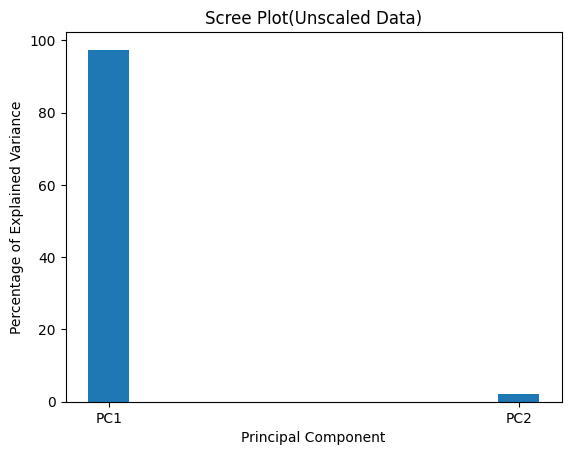

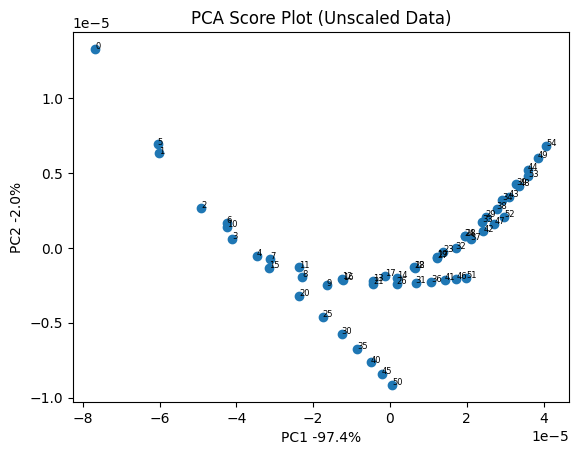

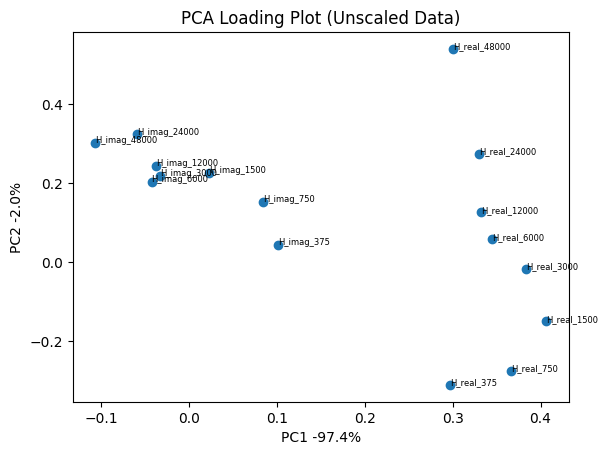

PC1 Loading Scores (Unscaled Data):
H_real_1500     0.406461
H_real_3000     0.383784
H_real_750      0.366108
H_real_6000     0.344800
H_real_12000    0.331822
H_real_24000    0.329722
H_real_48000    0.300752
H_real_375      0.296790
H_imag_48000   -0.106620
H_imag_375      0.101811
H_imag_750      0.084339
H_imag_24000   -0.059060
H_imag_6000    -0.042623
H_imag_12000   -0.037613
H_imag_3000    -0.033359
H_imag_1500     0.023242
Name: PC1, dtype: float64
PC2 Loading Scores (Unscaled Data):
H_real_48000    0.539446
H_imag_24000    0.323565
H_real_375     -0.310033
H_imag_48000    0.300945
H_real_750     -0.275677
H_real_24000    0.273833
H_imag_12000    0.244306
H_imag_1500     0.226308
H_imag_3000     0.218615
H_imag_6000     0.202741
H_imag_750      0.151895
H_real_1500    -0.149622
H_real_12000    0.125952
H_real_6000     0.057818
H_imag_375      0.043243
H_real_3000    -0.017335
Name: PC2, dtype: float64


In [17]:
unscaled_data = wide_df.iloc[:, 2:]
features = unscaled_data.columns.to_list()

un_loadings, un_scores = compute_pca(unscaled_data, 'Unscaled', features)

For <class 'type'> data


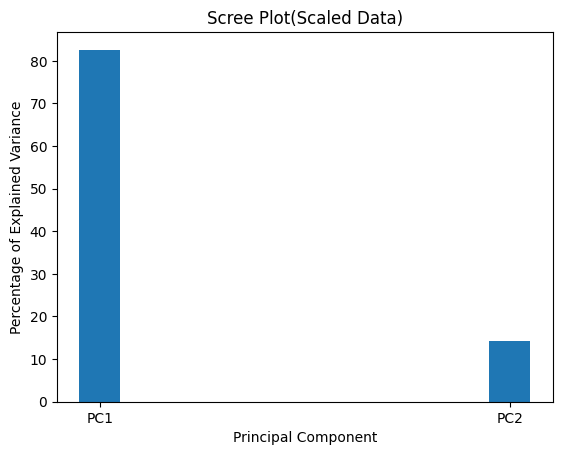

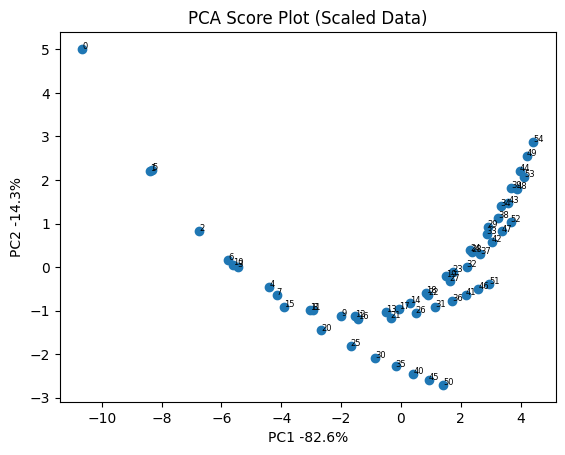

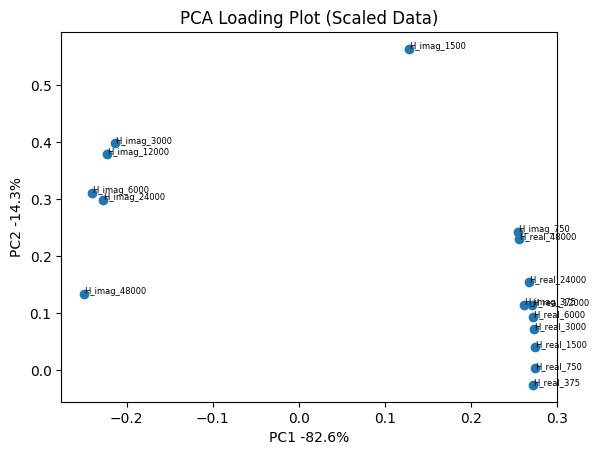

PC1 Loading Scores (Scaled Data):
H_real_1500     0.274101
H_real_750      0.274027
H_real_3000     0.273146
H_real_375      0.272469
H_real_6000     0.272190
H_real_12000    0.270885
H_real_24000    0.267287
H_imag_375      0.261824
H_real_48000    0.255556
H_imag_750      0.254763
H_imag_48000   -0.249702
H_imag_6000    -0.240565
H_imag_24000   -0.227475
H_imag_12000   -0.222402
H_imag_3000    -0.213045
H_imag_1500     0.128211
Name: PC1, dtype: float64
PC2 Loading Scores (Scaled Data):
H_imag_1500     0.563608
H_imag_3000     0.397651
H_imag_12000    0.378437
H_imag_6000     0.310223
H_imag_24000    0.298705
H_imag_750      0.242110
H_real_48000    0.229833
H_real_24000    0.154486
H_imag_48000    0.133227
H_real_12000    0.114607
H_imag_375      0.114450
H_real_6000     0.093561
H_real_3000     0.071992
H_real_1500     0.040266
H_real_375     -0.026226
H_real_750      0.002643
Name: PC2, dtype: float64


In [18]:
# Scaling data
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_data= scaler.fit_transform(unscaled_data)

sc_loadings, sc_scores = compute_pca(scaled_data, 'Scaled', features)

In [19]:
# Score-target correlations: correlate PCA sample scores with the targets
sc_score_target_corr = sc_scores.join(targets).corr(method='spearman')
print('PCA Score - Target Correlation (Spearman):')
sc_score_target_corr.loc[['PC1', 'PC2'], ['permeability', 'resistivity']]

NameError: name 'targets' is not defined

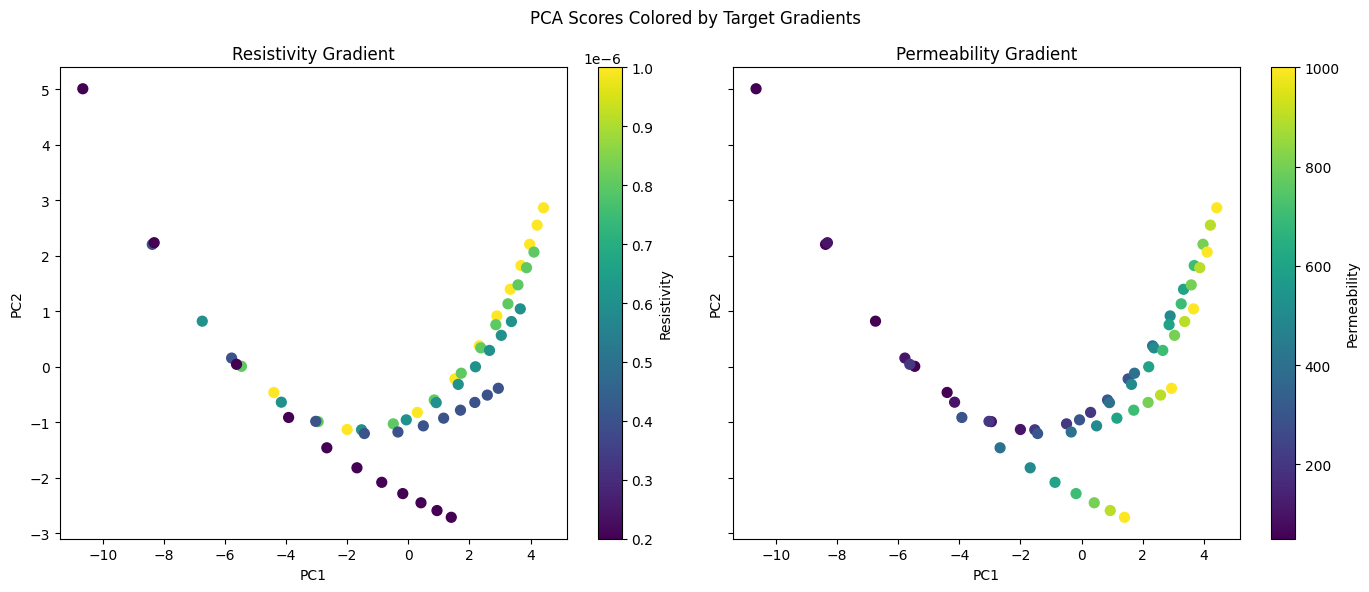

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)

scatter_res = axes[0].scatter(
    sc_scores['PC1'], sc_scores['PC2'],
    c=wide_df['resistivity'], cmap='viridis', s=50
)
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].set_title('Resistivity Gradient')
fig.colorbar(scatter_res, ax=axes[0], label='Resistivity')

scatter_perm = axes[1].scatter(
    sc_scores['PC1'], sc_scores['PC2'],
    c=wide_df['permeability'], cmap='viridis', s=50
)
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
axes[1].set_title('Permeability Gradient')
fig.colorbar(scatter_perm, ax=axes[1], label='Permeability')

fig.suptitle('PCA Scores Colored by Target Gradients')
fig.tight_layout()
plt.show()

    
## Result Summary Scaled PCA
- PC1 and PC2 combined explain ~97% of variance in data.

- The PCA loadings shows both H_real and H_imag features across all frequencies in PC1 with similar and strong weights with H_real having positive weights and H_imag having negative weights with a few exceptions of low frequency features (375, 750, and 1500)Hz having positive weights.  Also, compared to H_real feature weights, though similar, H_imag weights are on the smaller side.

- The sign flip of H_imag in PC1, which has a strong correlation with Permeability, is also observed in the inductance-frequency plot. At 375-1.5kHz the signals were in ascending order of permeability which slowly flipped after 1.5kHz. Similarly, in the Spearman Correlation Analysis, H_imag shows positive correlation with permeability at 375-1.5kHz before flipping to negative correlation across the remaining frequencies.

- On the other hand, PC2 has more H_imag values with strong positive weights at top with H_real at various frequencies with near-zero weights. 

- The PCA Score-Target Correlation also reinforces this pattern with PC1 showing strong positive correlation of ~0.84 with permeability and a moderate positive correlation of ~0.49 with resistivity and PC2 showing moderate correlation of ~0.48 with resistivity and near-zero correlation of ~0.12 with permeability. Hence, we can say that permeability is concentrated on PC1 and near-absent on PC2 and resistivity is spread between both PC1 and PC2 .

- This is roughly the same in case of unscaled too. PC1 corrrelation with permeability and resistivity was ~(0.79 and 0.55) and PC2 was ~(0.01 and 0.47).

- Since both real and imaginary features are bundled together in a single component, PC1 and just two components cover more than 95% of variance in the data, this suggests redundancy in the features.

- Additionally, the score plot has an arch shape  which is termed as horseshoe effect. This effect appears when the samples lie along a single dominant ordered gradient which has a non-linear relationship with the features. This causes a linear PCA to bend the gradient into an arch because it can't represent a curved structure with linear components. The gradient that drives the effect is permeability since it is strongly correlated with PC1 (~0.84) and the PCA Score - Permeability Gradient plot shows permeability following a linear shift horizontally from left to right along the dominant axis (PC1). Therefore, the horseshoe is consistent with a dominant nonlinear gradient and it's a known artifact of linear PCA straining against curved structure.

## Result Summary of EDA
- μr signal is strong. The inductance-frequency graph shows μr producing strong separation in H_real and in case of H_imag, the flipping effect suggests that μr's effect is strong. The Spearman Correlation also shows H_real having a strong positive correlation with μr across the frequencies and H_imag having strong positive correlation at low frequencies before flipping to strong negative correlations at higher frequenices. PCA also confirmed that μr is strong with ~0.84 correlation between PC1 and μr.

- ρ signal has repeatedly been seen as weak. The inductance-frequency graph shows ρ's effect is quite negligible on H_imag but shows moderate effect on H_real. The same is reflected by Spearman Correlation analysis. For H_imag, ρ shows moderate positive correlation at low frequencies and then drops to near-zero at high frequencies. For H_real, the correlation with ρ is moderate, consistent and positive across the frequencies. PCA also shows unlike μr, which is concentrated on PC1, ρ is distributed between PC1 and PC2.

- The information for μr and ρ is not cleanly split between H_real and H_imag. As mentioned in the above points, the targets have effect on both H_real and H_imag directly or indirectly. And the relationship between the variables is also non-linear as seen in the inductance-frequency plot and horseshoe effect in PCA is also consistent with non-linearity .